# Model 1 - Own CNN-model


In [38]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.utils import image_dataset_from_directory

This notebook covers the creation of our own CNN-model. The model is trained with the images taken by us.

Images can be found in the `2-Kuvantunnistus/images`- folder. 

The image dataset contains 5 classes, and they've been split into three sets (70%/15%/15%). 70% for training, 15% for validation and the last 15% for testing.

The 5 classes of images are:
- forks
- knives
- mugs
- pens
- spoons

In [39]:
batch_size = 32
img_size = (224, 224) # every image is 224x224 pixels

train_dataset = image_dataset_from_directory(
    "images/train",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

validation_dataset = image_dataset_from_directory(
    "images/validation",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

test_dataset = image_dataset_from_directory(
    "images/test",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

Found 175 files belonging to 5 classes.


Found 35 files belonging to 5 classes.
Found 40 files belonging to 5 classes.


In [40]:
data_augmentation = keras.Sequential(
    [   
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomTranslation(0.1, 0.1),
    ]
)

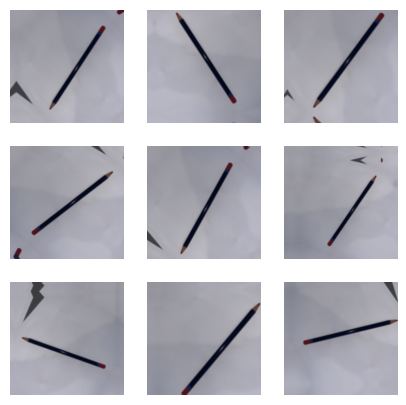

In [41]:
plt.figure(figsize=(5, 5))
for images, _ in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images, training=True)
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

In [42]:
model = Sequential([
    # Data augmentation
    data_augmentation,

    # Normalization
    layers.Rescaling(1./255),

    # CN layers
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(5, activation='softmax')  # 5 classes, thus 5 outputs
])

In [43]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



In [44]:
model.build(input_shape=(None, 224, 224, 3))  # batch_size None
model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_9 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 rescaling_5 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv2d_15 (Conv2D)          (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d_15 (MaxPooli  (None, 111, 111, 32)      0         
 ng2D)                                                           
                                                                 
 conv2d_16 (Conv2D)          (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_16 (MaxPooli  (None, 54, 54, 64)        0         
 ng2D)                                               

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
6/6 [==============================] - 1s 47ms/step - loss: 2.4395 - accuracy: 0.2171 - val_loss: 1.6001 - val_accuracy: 0.2000
Epoch 2/30
6/6 [==============================] - 0s 33ms/step - loss: 1.5173 - accuracy: 0.3143 - val_loss: 1.4498 - val_accuracy: 0.4286
Epoch 3/30
6/6 [==============================] - 0s 33ms/step - loss: 1.3236 - accuracy: 0.4000 - val_loss: 1.2980 - val_accuracy: 0.5143
Epoch 4/30
6/6 [==============================] - 0s 37ms/step - loss: 1.2311 - accuracy: 0.4229 - val_loss: 1.2549 - val_accuracy: 0.6000
Epoch 5/30
6/6 [==============================] - 0s 31ms/step - loss: 1.1292 - accuracy: 0.5314 - val_loss: 1.1239 - val_accuracy: 0.5143
Epoch 6/30
6/6 [==============================] - 0s 27ms/step - loss: 1.0202 - accuracy: 0.6000 - val_loss: 1.1084 - val_accuracy: 0.5143
Epoch 7/30
6/6 [==============================] - 0s 24ms/step - loss: 1.0064 - accuracy: 0.5371 - val_loss: 1.1365 - val_accuracy: 0.5429
Epoch 8/30
6/6 [===========

In [46]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.2f}")

2/2 [==============================] - 0s 7ms/step - loss: 0.7792 - accuracy: 0.7000
Test accuracy: 0.70


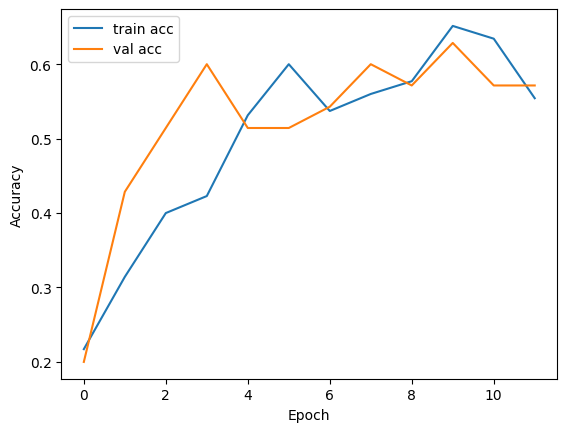

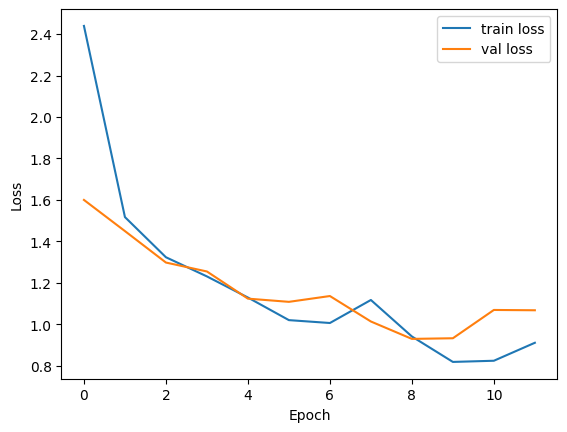

In [47]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()